# Sentiment Analysis Pipeline
### Feature Representations × Classifiers × Evaluation

**Columns:** `review_id`, `source`, `product_category`, `review_text`, `cleaned_text`, `tokens`, `token_count`, `rating`, `label`  
**Feature Representations:** TF-IDF (unigrams + bigrams) · Word2Vec (averaged embeddings)   
**Classifiers:** Logistic Regression · Linear SVM · Naive Bayes · Random Forest    
**Pipeline:** Load → Features → Baseline → Tuning → Top Features → Error Analysis → Report


### Imports & Setup

In [54]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection         import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.naive_bayes             import MultinomialNB, GaussianNB
from sklearn.metrics                 import (accuracy_score, precision_score,
                                             recall_score, f1_score,
                                             confusion_matrix, classification_report)
from sklearn.preprocessing           import LabelEncoder
from gensim.models                   import Word2Vec

print("✅  All libraries imported successfully.")


✅  All libraries imported successfully.


### Load & Inspect Data

Expected columns: `review_id`, `source`, `product_category`, `review_text`,
`cleaned_text`, `tokens` (pipe-separated string), `token_count`, `rating`, `label`


In [55]:
INPUT_FILE = "reviews_preprocessed.csv"
df = pd.read_csv(INPUT_FILE)

# Drop rows missing required fields
df.dropna(subset=["cleaned_text", "label"], inplace=True)
df["cleaned_text"] = df["cleaned_text"].astype(str)

# tokens column is stored as a pipe-separated string ("word | word | word")
# Convert to a proper list of tokens
df["tokens"] = df["tokens"].astype(str).apply(
    lambda s: [t.strip() for t in s.split("|") if t.strip()]
)

print(f"📂  Loaded {len(df):,} reviews")
print(f"\nColumns : {list(df.columns)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nClass balance (%):\n{df['label'].value_counts(normalize=True).mul(100).round(2)}")
print(f"\nRating distribution:\n{df['rating'].value_counts().sort_index()}")
print(f"\nZero-length token lists: {df['tokens'].apply(len).eq(0).sum()}")
display(df[["review_id", "source", "product_category", "rating", "label", "cleaned_text"]].head())


📂  Loaded 1,110 reviews

Columns : ['review_id', 'source', 'product_category', 'review_text', 'cleaned_text', 'tokens', 'token_count', 'rating', 'label']

Label distribution:
label
positive    370
negative    370
neutral     370
Name: count, dtype: int64

Class balance (%):
label
positive    33.33
negative    33.33
neutral     33.33
Name: proportion, dtype: float64

Rating distribution:
rating
1    292
2     78
3    370
4    140
5    230
Name: count, dtype: int64

Zero-length token lists: 0


,review_id,source,product_category,rating,label,cleaned_text
0,REV00001,Google Play Store,Games - Endless Runner,5,positive,game amaze much fun advertise make n't pay mon...
1,REV00002,Google Play Store,Games - Strategy,1,negative,'m really mad one reason whole game experience...
2,REV00003,Google Play Store,Games - Sandbox,1,negative,dont get realistic b platform good game okay e...
3,REV00004,Google Play Store,Games - Action RPG,3,neutral,genshin impact amaze game stun graphic immersi...
4,REV00005,Google Play Store,Games - MOBA,3,neutral,overall gameplay graphic event mode great real...


### Label Encoding & Train/Test Split (Stratified 80/20)

In [56]:
LABELS = sorted(df["label"].unique().tolist())   # derived from data
print(f"Classes found in data: {LABELS}")

le = LabelEncoder()
le.fit(LABELS)
y      = le.transform(df["label"])
X_text = df["cleaned_text"].values

# Stratified 80/20 split — record original indices for error analysis
all_indices = np.arange(len(df))
train_pos, test_pos = train_test_split(
    all_indices, test_size=0.20, random_state=42, stratify=y
)

X_train_text = X_text[train_pos]
X_test_text  = X_text[test_pos]
y_train      = y[train_pos]
y_test       = y[test_pos]

print(f"\n✂️  Train : {len(X_train_text):,}  |  Test : {len(X_test_text):,}")
print(f"Train label dist : { {l: int((y_train == i).sum()) for i, l in enumerate(LABELS)} }")
print(f"Test  label dist : { {l: int((y_test  == i).sum()) for i, l in enumerate(LABELS)} }")


Classes found in data: ['negative', 'neutral', 'positive']

✂️  Train : 888  |  Test : 222
Train label dist : {'negative': 296, 'neutral': 296, 'positive': 296}
Test  label dist : {'negative': 74, 'neutral': 74, 'positive': 74}


### Feature Representation 1 — TF-IDF (unigrams + bigrams)

Built from `cleaned_text`. Fit only on train to prevent leakage.


In [57]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=20_000,
    sublinear_tf=True,    # log(tf)+1 smoothing
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"✅  TF-IDF vocab : {len(tfidf.vocabulary_):,} features")
print(f"    Train matrix : {X_train_tfidf.shape}")
print(f"    Test  matrix : {X_test_tfidf.shape}")


✅  TF-IDF vocab : 5,013 features
    Train matrix : (888, 5013)
    Test  matrix : (222, 5013)


### Feature Representation 2 — Word2Vec (Averaged Embeddings)

Uses the pre-tokenised `tokens` column (pipe-separated → list).
Word2Vec is trained on the full corpus (unsupervised step — no label leakage).
Each document is represented as the mean of its word vectors.


In [58]:
all_token_lists = df["tokens"].tolist()   # list of lists

W2V_DIM = 100
w2v_model = Word2Vec(
    sentences=all_token_lists,
    vector_size=W2V_DIM,
    window=5,
    min_count=1,
    workers=4,
    seed=42,
    epochs=10,
)
print(f"✅  Word2Vec vocab : {len(w2v_model.wv):,} words  |  dim = {W2V_DIM}")

def tokens_to_w2v(token_lists):
    """Average word vectors for a list of token lists."""
    vecs = []
    for tokens in token_lists:
        valid = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        vecs.append(np.mean(valid, axis=0) if valid else np.zeros(W2V_DIM))
    return np.array(vecs)

# Use train token lists only (indexed by position)
train_tokens = df["tokens"].iloc[train_pos].tolist()
test_tokens  = df["tokens"].iloc[test_pos].tolist()

X_train_w2v = tokens_to_w2v(train_tokens)
X_test_w2v  = tokens_to_w2v(test_tokens)

# Non-negative shift for MultinomialNB; use TRAIN min to avoid leakage
w2v_min = X_train_w2v.min()
X_train_w2v_nn = X_train_w2v - w2v_min
X_test_w2v_nn  = X_test_w2v  - w2v_min

print(f"    Train W2V shape : {X_train_w2v.shape}")
print(f"    Test  W2V shape : {X_test_w2v.shape}")
print(f"    Zero vectors in test : {(X_test_w2v == 0).all(axis=1).sum()}")


✅  Word2Vec vocab : 4,046 words  |  dim = 100
    Train W2V shape : (888, 100)
    Test  W2V shape : (222, 100)
    Zero vectors in test : 0


### Evaluation & Helper Functions

In [59]:
def evaluate_model(model, X_train, X_test, y_train, y_test,
                   vectorizer=None, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score   (y_test, y_pred, average="macro", zero_division=0)
    f1m  = f1_score       (y_test, y_pred, average="macro", zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    cr   = classification_report(y_test, y_pred, target_names=LABELS, zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  |  F1-Macro : {f1m:.4f}")
    print(f"\n{cr}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(model_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {"name": model_name, "clf": model, "y_pred": y_pred,
            "acc": acc, "prec": prec, "rec": rec, "f1_macro": f1m,
            "cm": cm, "report": cr}


def show_top_features(model, vectorizer, model_name="Model", top_n=15):
    print(f"\n{'='*55}")
    print(f"  TOP FEATURES — {model_name}")
    print(f"{'='*55}")
    if not hasattr(model, "coef_"):
        print("  ⚠️  Model does not expose coefficients.")
        return
    feature_names = np.array(vectorizer.get_feature_names_out())
    for i, label in enumerate(LABELS):
        coefs = model.coef_[i] if model.coef_.ndim > 1 else model.coef_[0]
        top_pos = feature_names[np.argsort(coefs)[-top_n:]][::-1]
        top_neg = feature_names[np.argsort(coefs)[:top_n]]
        print(f"\n  [{label.upper()}]")
        print(f"    Most positive : {', '.join(top_pos)}")
        print(f"    Most negative : {', '.join(top_neg)}")


def error_analysis(model, X_test_vec, y_test_enc, model_name="Model", n=10):
    print(f"\n{'='*55}")
    print(f"  ERROR ANALYSIS — {model_name}")
    print(f"{'='*55}")
    y_pred = model.predict(X_test_vec)
    mis    = np.where(y_pred != y_test_enc)[0]
    print(f"  Total misclassified : {len(mis):,}  |  Showing {min(n, len(mis))}\n")
    for k, pos in enumerate(mis[:n]):
        true_label = le.inverse_transform([y_test_enc[pos]])[0]
        pred_label = le.inverse_transform([y_pred[pos]])[0]
        orig_idx   = test_pos[pos]
        review     = df.iloc[orig_idx]["cleaned_text"]
        rating     = df.iloc[orig_idx]["rating"]
        print(f"  [{k+1:02d}]  TRUE: {true_label:<10}  PRED: {pred_label:<10}  Rating: {rating}")
        print(f"       {str(review)[:250]}")
        print()


print("✅  Helper functions defined.")


✅  Helper functions defined.


##  Baseline Models (Default Hyperparameters)

### Logistic Regression


  LR + TF-IDF (baseline)
  Accuracy  : 0.5856  |  F1-Macro : 0.5799

              precision    recall  f1-score   support

    negative       0.58      0.70      0.63        74
     neutral       0.53      0.42      0.47        74
    positive       0.64      0.64      0.64        74

    accuracy                           0.59       222
   macro avg       0.58      0.59      0.58       222
weighted avg       0.58      0.59      0.58       222



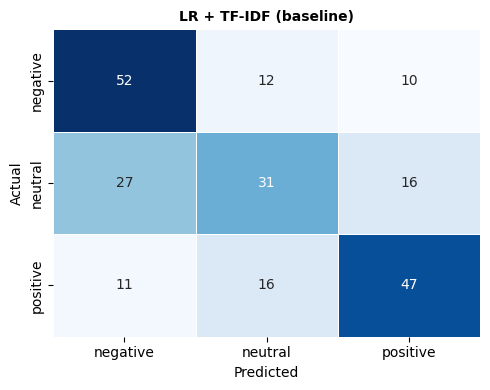


  LR + Word2Vec (baseline)
  Accuracy  : 0.4910  |  F1-Macro : 0.4860

              precision    recall  f1-score   support

    negative       0.57      0.38      0.46        74
     neutral       0.46      0.46      0.46        74
    positive       0.47      0.64      0.54        74

    accuracy                           0.49       222
   macro avg       0.50      0.49      0.49       222
weighted avg       0.50      0.49      0.49       222



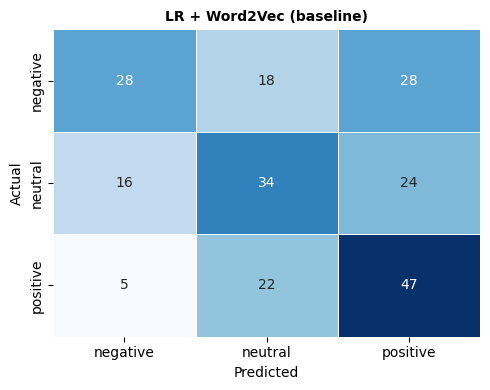

In [60]:
all_results = []

r = evaluate_model(LogisticRegression(max_iter=1000, random_state=42),
                   X_train_tfidf, X_test_tfidf, y_train, y_test,
                   vectorizer=tfidf, model_name="LR + TF-IDF (baseline)")
all_results.append(r)

r = evaluate_model(LogisticRegression(max_iter=1000, random_state=42),
                   X_train_w2v, X_test_w2v, y_train, y_test,
                   model_name="LR + Word2Vec (baseline)")
all_results.append(r)


### Linear SVM


  SVM + TF-IDF (baseline)
  Accuracy  : 0.5495  |  F1-Macro : 0.5424

              precision    recall  f1-score   support

    negative       0.57      0.65      0.61        74
     neutral       0.43      0.35      0.39        74
    positive       0.62      0.65      0.63        74

    accuracy                           0.55       222
   macro avg       0.54      0.55      0.54       222
weighted avg       0.54      0.55      0.54       222



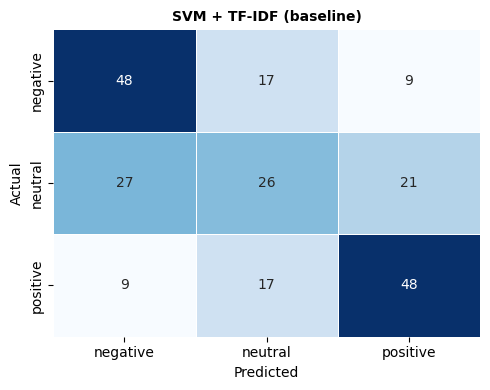


  SVM + Word2Vec (baseline)
  Accuracy  : 0.5000  |  F1-Macro : 0.4849

              precision    recall  f1-score   support

    negative       0.55      0.45      0.49        74
     neutral       0.47      0.31      0.37        74
    positive       0.49      0.74      0.59        74

    accuracy                           0.50       222
   macro avg       0.50      0.50      0.48       222
weighted avg       0.50      0.50      0.48       222



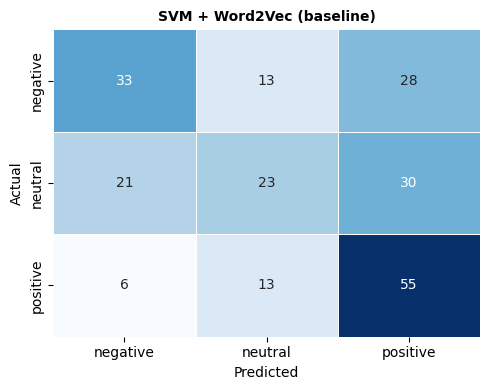

In [61]:
r = evaluate_model(LinearSVC(C=1.0, max_iter=3000, random_state=42),
                   X_train_tfidf, X_test_tfidf, y_train, y_test,
                   vectorizer=tfidf, model_name="SVM + TF-IDF (baseline)")
all_results.append(r)

r = evaluate_model(LinearSVC(C=1.0, max_iter=3000, random_state=42),
                   X_train_w2v, X_test_w2v, y_train, y_test,
                   model_name="SVM + Word2Vec (baseline)")
all_results.append(r)


### Naive Bayes


  NB MultinomialNB + TF-IDF (baseline)
  Accuracy  : 0.6126  |  F1-Macro : 0.6143

              precision    recall  f1-score   support

    negative       0.64      0.61      0.62        74
     neutral       0.52      0.57      0.54        74
    positive       0.69      0.66      0.68        74

    accuracy                           0.61       222
   macro avg       0.62      0.61      0.61       222
weighted avg       0.62      0.61      0.61       222



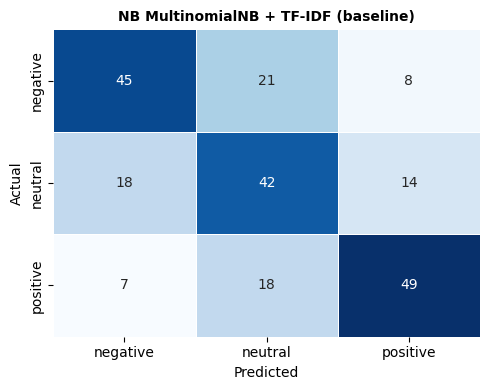


  NB GaussianNB + Word2Vec (baseline)
  Accuracy  : 0.3604  |  F1-Macro : 0.3556

              precision    recall  f1-score   support

    negative       0.38      0.46      0.41        74
     neutral       0.34      0.36      0.35        74
    positive       0.36      0.26      0.30        74

    accuracy                           0.36       222
   macro avg       0.36      0.36      0.36       222
weighted avg       0.36      0.36      0.36       222



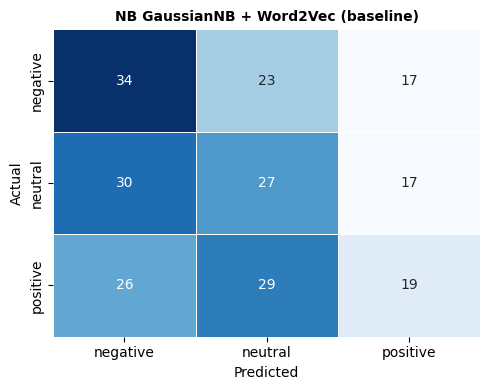

In [62]:
# TF-IDF → MultinomialNB (non-negative sparse matrix ✅)
r = evaluate_model(MultinomialNB(alpha=0.5),
                   X_train_tfidf, X_test_tfidf, y_train, y_test,
                   vectorizer=tfidf, model_name="NB MultinomialNB + TF-IDF (baseline)")
all_results.append(r)

# Word2Vec → GaussianNB (real-valued dense vectors ✅)
r = evaluate_model(GaussianNB(),
                   X_train_w2v, X_test_w2v, y_train, y_test,
                   model_name="NB GaussianNB + Word2Vec (baseline)")
all_results.append(r)


### Baseline Summary

In [63]:
print("\n" + "="*72)
print("  BASELINE PERFORMANCE SUMMARY")
print("="*72)
print(f"{'Model':<40} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*72)
for r in all_results:
    print(f"{r['name']:<40} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")



  BASELINE PERFORMANCE SUMMARY
Model                                         Acc     Prec      Rec       F1
------------------------------------------------------------------------
LR + TF-IDF (baseline)                     0.5856   0.5823   0.5856   0.5799
LR + Word2Vec (baseline)                   0.4910   0.5019   0.4910   0.4860
SVM + TF-IDF (baseline)                    0.5495   0.5400   0.5495   0.5424
SVM + Word2Vec (baseline)                  0.5000   0.5020   0.5000   0.4849
NB MultinomialNB + TF-IDF (baseline)       0.6126   0.6172   0.6126   0.6143
NB GaussianNB + Word2Vec (baseline)        0.3604   0.3593   0.3604   0.3556


## Hyperparameter Tuning

In [64]:
def tune_and_evaluate(model_factory, param_grid,
                      X_train, X_test, y_train, y_test,
                      vectorizer=None, model_name="Model"):
    """GridSearchCV wrapper. model_factory is a zero-arg callable returning a fresh estimator."""
    grid = GridSearchCV(
        model_factory(), param_grid,
        cv=3, scoring="f1_macro", n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    print(f"\n🔍  {model_name}")
    print(f"    Best params : {grid.best_params_}")
    print(f"    CV F1-macro : {grid.best_score_:.4f}")
    r = evaluate_model(
        grid.best_estimator_, X_train, X_test, y_train, y_test,
        vectorizer=vectorizer, model_name=f"{model_name} (tuned)"
    )
    return grid.best_estimator_, r

tuned_results = []
print("✅  tune_and_evaluate defined.")


✅  tune_and_evaluate defined.


### Logistic Regression — Tuned


🔍  Logistic Regression (TF-IDF)
    Best params : {'C': 0.1, 'solver': 'saga'}
    CV F1-macro : 0.5293

  Logistic Regression (TF-IDF) (tuned)
  Accuracy  : 0.6171  |  F1-Macro : 0.6098

              precision    recall  f1-score   support

    negative       0.62      0.74      0.67        74
     neutral       0.57      0.43      0.49        74
    positive       0.65      0.68      0.66        74

    accuracy                           0.62       222
   macro avg       0.61      0.62      0.61       222
weighted avg       0.61      0.62      0.61       222



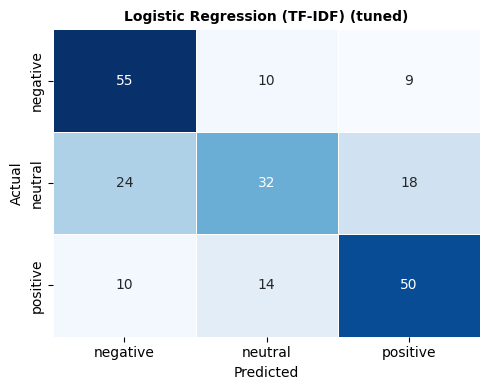


🔍  Logistic Regression (Word2Vec)
    Best params : {'C': 10, 'solver': 'saga'}
    CV F1-macro : 0.4861

  Logistic Regression (Word2Vec) (tuned)
  Accuracy  : 0.5180  |  F1-Macro : 0.5044

              precision    recall  f1-score   support

    negative       0.54      0.53      0.53        74
     neutral       0.49      0.31      0.38        74
    positive       0.51      0.72      0.60        74

    accuracy                           0.52       222
   macro avg       0.52      0.52      0.50       222
weighted avg       0.52      0.52      0.50       222



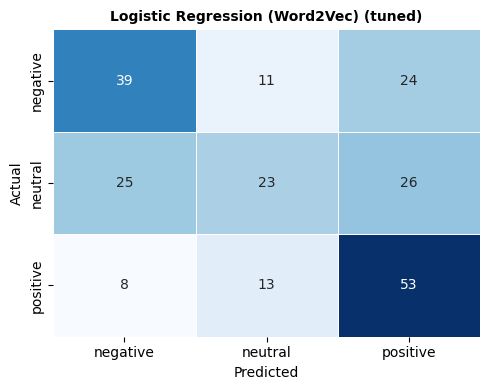

In [65]:
param_lr = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "saga"]}

best_lr_tfidf, r = tune_and_evaluate(
    lambda: LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_lr, X_train_tfidf, X_test_tfidf, y_train, y_test,
    vectorizer=tfidf, model_name="Logistic Regression (TF-IDF)")
tuned_results.append(r)

best_lr_w2v, r = tune_and_evaluate(
    lambda: LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_lr, X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="Logistic Regression (Word2Vec)")
tuned_results.append(r)


### Linear SVM — Tuned


🔍  Linear SVM (TF-IDF)
    Best params : {'C': 0.1}
    CV F1-macro : 0.5214

  Linear SVM (TF-IDF) (tuned)
  Accuracy  : 0.5946  |  F1-Macro : 0.5841

              precision    recall  f1-score   support

    negative       0.59      0.73      0.65        74
     neutral       0.55      0.38      0.45        74
    positive       0.63      0.68      0.65        74

    accuracy                           0.59       222
   macro avg       0.59      0.59      0.58       222
weighted avg       0.59      0.59      0.58       222



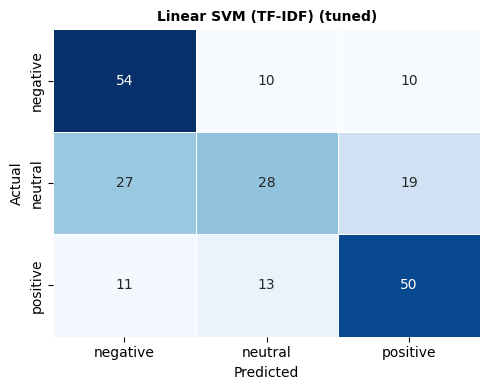


🔍  Linear SVM (Word2Vec)
    Best params : {'C': 10}
    CV F1-macro : 0.5013

  Linear SVM (Word2Vec) (tuned)
  Accuracy  : 0.5541  |  F1-Macro : 0.5378

              precision    recall  f1-score   support

    negative       0.62      0.65      0.63        74
     neutral       0.51      0.30      0.38        74
    positive       0.52      0.72      0.61        74

    accuracy                           0.55       222
   macro avg       0.55      0.55      0.54       222
weighted avg       0.55      0.55      0.54       222



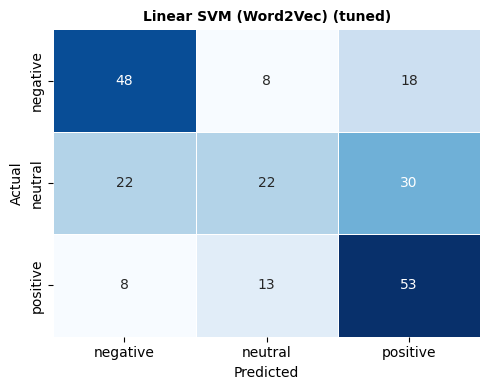

In [66]:
param_svm = {"C": [0.1, 1, 10]}

best_svm_tfidf, r = tune_and_evaluate(
    lambda: LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
    param_svm, X_train_tfidf, X_test_tfidf, y_train, y_test,
    vectorizer=tfidf, model_name="Linear SVM (TF-IDF)")
tuned_results.append(r)

best_svm_w2v, r = tune_and_evaluate(
    lambda: LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
    param_svm, X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="Linear SVM (Word2Vec)")
tuned_results.append(r)


### Naive Bayes — Tuned


🔍  NB MultinomialNB (TF-IDF)
    Best params : {'alpha': 5.0}
    CV F1-macro : 0.5286

  NB MultinomialNB (TF-IDF) (tuned)
  Accuracy  : 0.6306  |  F1-Macro : 0.6285

              precision    recall  f1-score   support

    negative       0.64      0.73      0.68        74
     neutral       0.57      0.53      0.55        74
    positive       0.67      0.64      0.65        74

    accuracy                           0.63       222
   macro avg       0.63      0.63      0.63       222
weighted avg       0.63      0.63      0.63       222



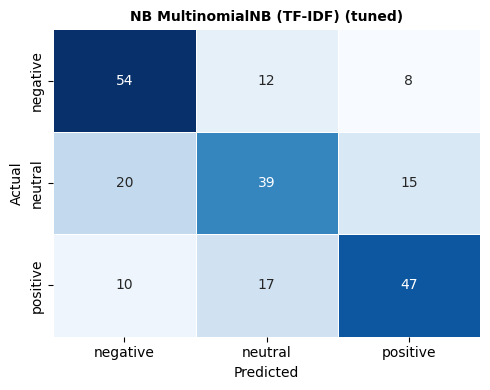


🔍  NB GaussianNB (Word2Vec)
    Best params : {'var_smoothing': 1e-09}
    CV F1-macro : 0.3968

  NB GaussianNB (Word2Vec) (tuned)
  Accuracy  : 0.3604  |  F1-Macro : 0.3556

              precision    recall  f1-score   support

    negative       0.38      0.46      0.41        74
     neutral       0.34      0.36      0.35        74
    positive       0.36      0.26      0.30        74

    accuracy                           0.36       222
   macro avg       0.36      0.36      0.36       222
weighted avg       0.36      0.36      0.36       222



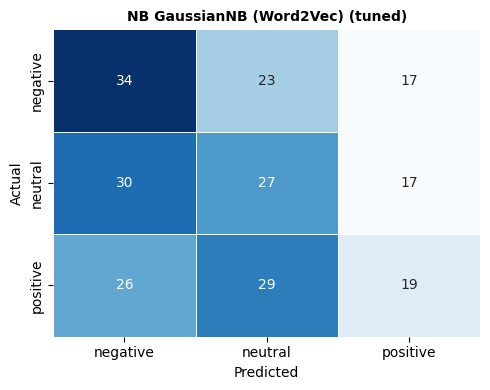

In [67]:
# TF-IDF: MultinomialNB
param_nb_tfidf = {"alpha": [0.1, 0.5, 1.0, 5.0]}
best_nb_tfidf, r = tune_and_evaluate(
    MultinomialNB, param_nb_tfidf,
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    vectorizer=tfidf, model_name="NB MultinomialNB (TF-IDF)")
tuned_results.append(r)

# Word2Vec: GaussianNB
param_nb_w2v = {"var_smoothing": [1e-9, 1e-8, 1e-7]}
best_nb_w2v, r = tune_and_evaluate(
    GaussianNB, param_nb_w2v,
    X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="NB GaussianNB (Word2Vec)")
tuned_results.append(r)


### Tuned Summary

In [68]:
print("\n" + "="*72)
print("  TUNED MODEL PERFORMANCE SUMMARY")
print("="*72)
print(f"{'Model':<42} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*72)
for r in tuned_results:
    print(f"{r['name']:<42} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")

best_tuned = max(tuned_results, key=lambda r: r["f1_macro"])
print(f"\n🏆  Best tuned model : {best_tuned['name']}  (F1-macro = {best_tuned['f1_macro']:.4f})")



  TUNED MODEL PERFORMANCE SUMMARY
Model                                           Acc     Prec      Rec       F1
------------------------------------------------------------------------
Logistic Regression (TF-IDF) (tuned)         0.6171   0.6129   0.6171   0.6098
Logistic Regression (Word2Vec) (tuned)       0.5180   0.5152   0.5180   0.5044
Linear SVM (TF-IDF) (tuned)                  0.5946   0.5896   0.5946   0.5841
Linear SVM (Word2Vec) (tuned)                0.5541   0.5506   0.5541   0.5378
NB MultinomialNB (TF-IDF) (tuned)            0.6306   0.6293   0.6306   0.6285
NB GaussianNB (Word2Vec) (tuned)             0.3604   0.3593   0.3604   0.3556

🏆  Best tuned model : NB MultinomialNB (TF-IDF) (tuned)  (F1-macro = 0.6285)


## Combined Confusion Matrix Grid — All Tuned Models

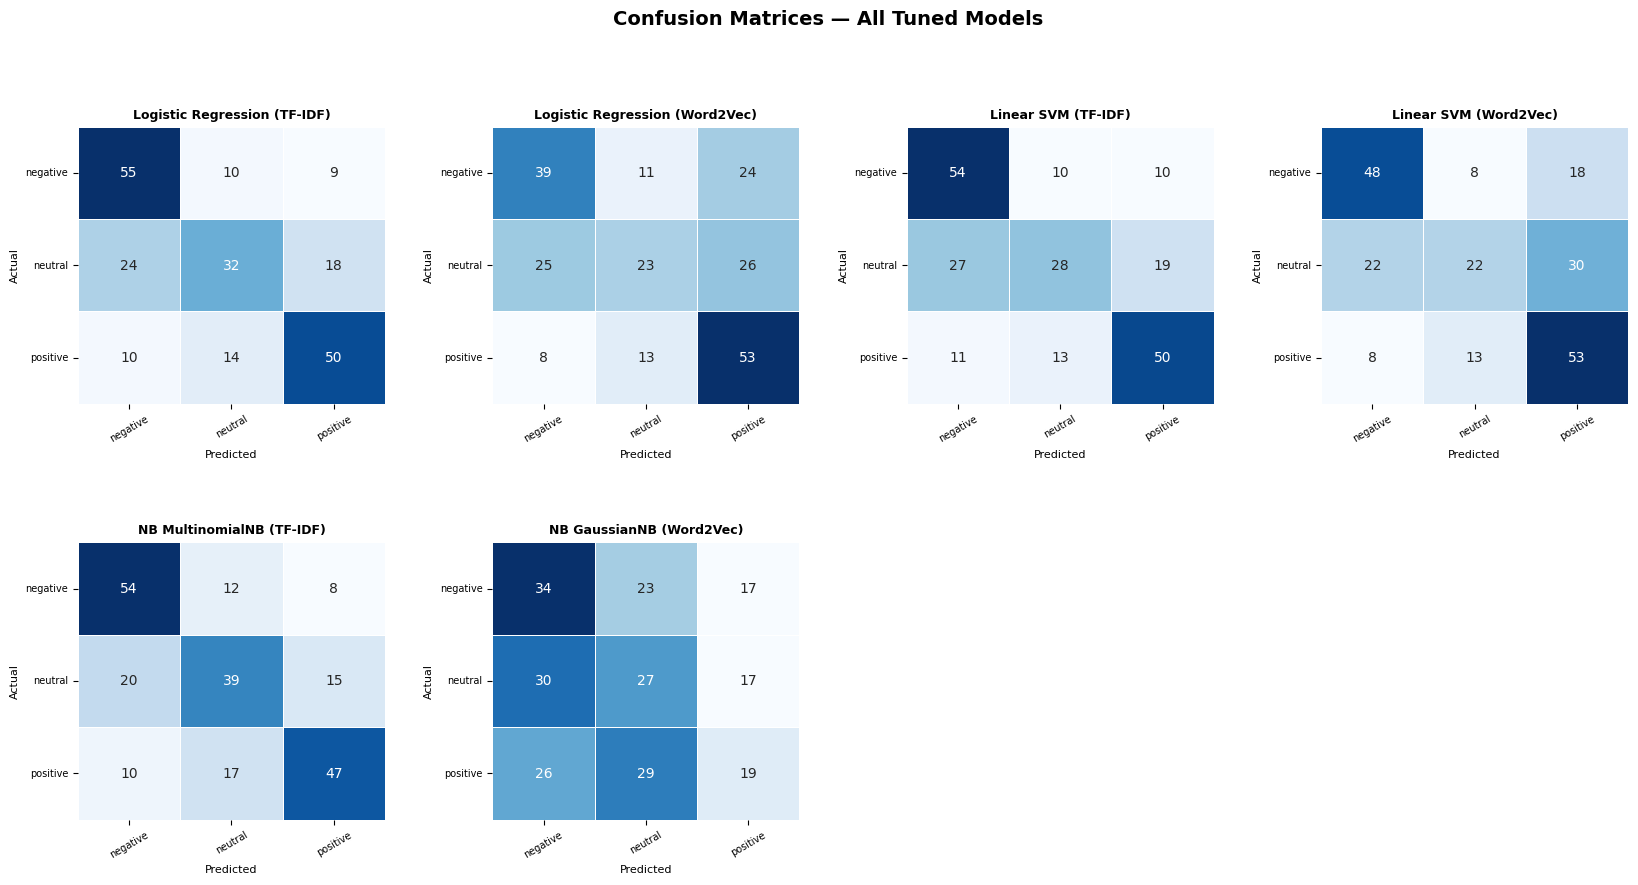

✅  Saved → confusion_matrices.png


In [69]:
n_models = len(tuned_results)
cols = 4
rows = (n_models + cols - 1) // cols

fig = plt.figure(figsize=(5 * cols, 4.5 * rows))
fig.suptitle("Confusion Matrices — All Tuned Models", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.5, wspace=0.35)

for idx, r in enumerate(tuned_results):
    row, col = divmod(idx, cols)
    ax = fig.add_subplot(gs[row, col])
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(r["name"].replace(" (tuned)", ""), fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual",    fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅  Saved → confusion_matrices.png")


## Top Features — Linear Models (TF-IDF)

Logistic Regression and LinearSVC expose per-class coefficient vectors that map
directly to TF-IDF vocabulary indices, revealing the most predictive n-grams.


In [70]:
show_top_features(best_lr_tfidf,  tfidf, "Logistic Regression (TF-IDF) — Tuned")
show_top_features(best_svm_tfidf, tfidf, "Linear SVM (TF-IDF) — Tuned")



  TOP FEATURES — Logistic Regression (TF-IDF) — Tuned

  [NEGATIVE]
    Most positive : not, money, worse, win, worst, player, face, spend, lose, bot, even, update, trash, frustrate, teammate
    Most negative : love, like, best, graphic, fun, star, good, amaze, really, sometimes, world, great, nice, something, different

  [NEUTRAL]
    Most positive : annoy, thing, time, something, need, sometimes, ca, crash, connection, app, ad, get, like, th, not
    Most negative : best, character, mobile, graphic, make game, ever, game, experience, see, event, one, win, coin, royale, game ever

  [POSITIVE]
    Most positive : best, graphic, fun, love, mobile, amaze, character, world, great, one best, one, excite, different, game, would
    Most negative : not, get, even, money, annoy, time, app, fix, matchmaking, ca, stop, update, bot, connection, lose

  TOP FEATURES — Linear SVM (TF-IDF) — Tuned

  [NEGATIVE]
    Most positive : not, worst, worse, face, win, bot, money, lose, spend, trash, fr

## Error Analysis — Best Tuned Models

Inspect 10 misclassified reviews to identify systematic failure patterns.
The `rating` column from the original data is shown alongside each example.


In [71]:
error_analysis(best_lr_tfidf, X_test_tfidf, y_test,
               model_name="Logistic Regression (TF-IDF) — Tuned", n=10)

error_analysis(best_lr_w2v, X_test_w2v, y_test,
               model_name="Logistic Regression (Word2Vec) — Tuned", n=10)



  ERROR ANALYSIS — Logistic Regression (TF-IDF) — Tuned
  Total misclassified : 85  |  Showing 10

  [01]  TRUE: positive    PRED: negative    Rating: 4
       've day log know not people like 's literally free no add get update every month even year release

  [02]  TRUE: neutral     PRED: positive    Rating: 3
       thing hate game 's no 'log feature recently want log old account main mail accidentally forget email account link click different email 'm stick account dont anything check everywhere n't find 'log feature would love add one tho

  [03]  TRUE: negative    PRED: positive    Rating: 1
       freefire excite mobile game short match time perfect quick burst gameplay variety weapon character keep thing interest account get hack recovery email change report free fire expect intervene ignore account go forever expect download open new account

  [04]  TRUE: negative    PRED: neutral     Rating: 1
       love game latest update break black screen death although actually load ca

## Error Discussion

Common failure patterns based on the `cleaned_text`, `label`, and `rating` columns:

1. **Neutral ↔ Positive confusion** — Mixed reviews (rating 3–4) contain positive vocabulary
   ("fun", "good") alongside complaints; the model favours the positive lexicon.

2. **Neutral ↔ Negative confusion** — Short negative reviews yield sparse TF-IDF vectors and
   W2V averages close to the neutral centroid.

3. **Irony / sarcasm** — Phrases that are lexically positive but contextually negative
   (e.g., *"great job breaking the game again"*) fool bag-of-words representations.

4. **Rating–label mismatch** — A rating-3 review may read positive or negative depending on
   the user's phrasing, introducing ground-truth noise.

5. **Rare vocabulary** — Words absent from the training corpus produce zero W2V vectors,
   reducing document representation quality for short or specialised reviews.


## Save Full Results Report → `results_summary.txt`

In [72]:
SEP = "=" * 65
lines = [SEP, "  SENTIMENT ANALYSIS — FULL RESULTS REPORT", SEP]

lines += ["\n── DATA SUMMARY ─────────────────────────────────────────────"]
lines += [df["label"].value_counts().to_string()]
lines += [f"\n  Total samples : {len(df):,}",
          f"  Train / Test  : {len(X_train_text):,} / {len(X_test_text):,}  (80/20 stratified)"]

lines += ["\n\n── BASELINE PERFORMANCE ────────────────────────────────────"]
lines += [f"{'Model':<40} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}", "-"*65]
for r in all_results:
    lines.append(f"{r['name']:<40} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")

lines += ["\n\n── TUNED PERFORMANCE ───────────────────────────────────────"]
lines += [f"{'Model':<42} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}", "-"*65]
for r in tuned_results:
    lines.append(f"{r['name']:<42} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")

best_tuned = max(tuned_results, key=lambda r: r["f1_macro"])
lines += [f"\n\n── BEST MODEL ──────────────────────────────────────────────",
          f"  {best_tuned['name']}  (F1-macro = {best_tuned['f1_macro']:.4f})"]

lines += ["\n\n── PER-CLASS REPORTS (TUNED) ────────────────────────────────"]
for r in tuned_results:
    lines += [f"\n{'─'*40}", f"  {r['name']}", f"{'─'*40}", r["report"]]

lines += [SEP, "  END OF REPORT", SEP]

report_text = "\n".join(lines)
with open("results_summary.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("\n✅  Saved → results_summary.txt")
print("✅  Saved → confusion_matrices.png")


  SENTIMENT ANALYSIS — FULL RESULTS REPORT

── DATA SUMMARY ─────────────────────────────────────────────
label
positive    370
negative    370
neutral     370

  Total samples : 1,110
  Train / Test  : 888 / 222  (80/20 stratified)


── BASELINE PERFORMANCE ────────────────────────────────────
Model                                         Acc     Prec      Rec       F1
-----------------------------------------------------------------
LR + TF-IDF (baseline)                     0.5856   0.5823   0.5856   0.5799
LR + Word2Vec (baseline)                   0.4910   0.5019   0.4910   0.4860
SVM + TF-IDF (baseline)                    0.5495   0.5400   0.5495   0.5424
SVM + Word2Vec (baseline)                  0.5000   0.5020   0.5000   0.4849
NB MultinomialNB + TF-IDF (baseline)       0.6126   0.6172   0.6126   0.6143
NB GaussianNB + Word2Vec (baseline)        0.3604   0.3593   0.3604   0.3556


── TUNED PERFORMANCE ───────────────────────────────────────
Model                               